In [2]:
pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf

In [6]:
apple_stock = pd.read_csv('/content/Apple Stock Prices (1981 to 2023).csv')
apple_stock.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [7]:
apple_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 580.3+ KB


In [8]:
print("Dataset Shape:", apple_stock.shape)
print("\nColumn Names:")
print(apple_stock.columns.tolist())

Dataset Shape: (10608, 7)

Column Names:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [9]:
apple_stock.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09


In [10]:
print("Duplicate rows:", apple_stock.duplicated().sum())

Duplicate rows: 0


In [11]:
apple_stock.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [12]:
# convert Date column
apple_stock["Date"] = pd.to_datetime(apple_stock["Date"], dayfirst=True)

In [13]:
# Create new columns
apple_stock["Year"] = apple_stock["Date"].dt.year
apple_stock["Month"] = apple_stock["Date"].dt.month
apple_stock["DayOfWeek"] = apple_stock["Date"].dt.day_name()

In [14]:
apple_stock.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,DayOfWeek
0,1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800,1981,1,Friday
1,1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000,1981,1,Monday
2,1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400,1981,1,Tuesday
3,1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400,1981,1,Wednesday
4,1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200,1981,1,Thursday


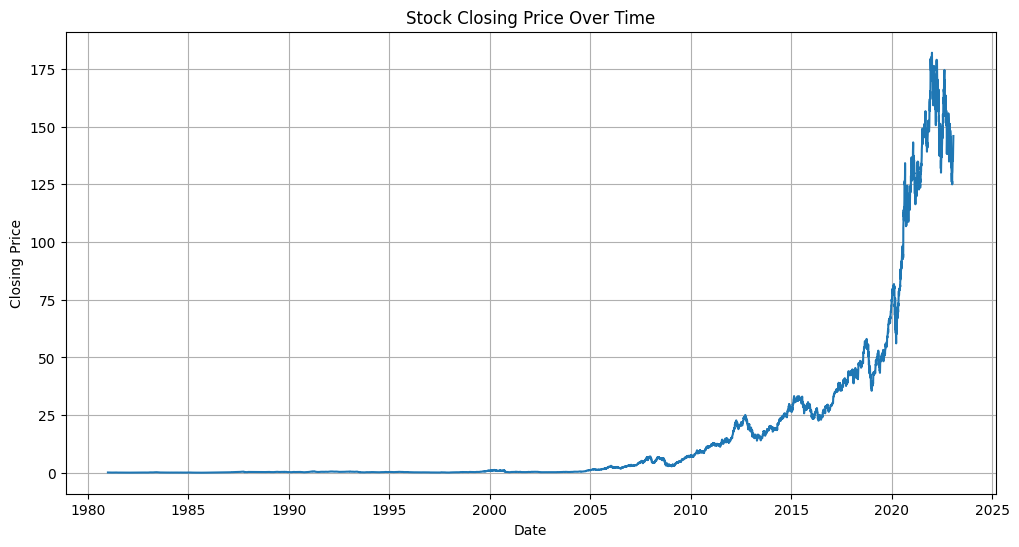

In [15]:
# sort values
apple_stock = apple_stock.sort_values("Date")

# plot
plt.figure(figsize=(12,6))
plt.plot(apple_stock["Date"], apple_stock["Close"])

plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.show()

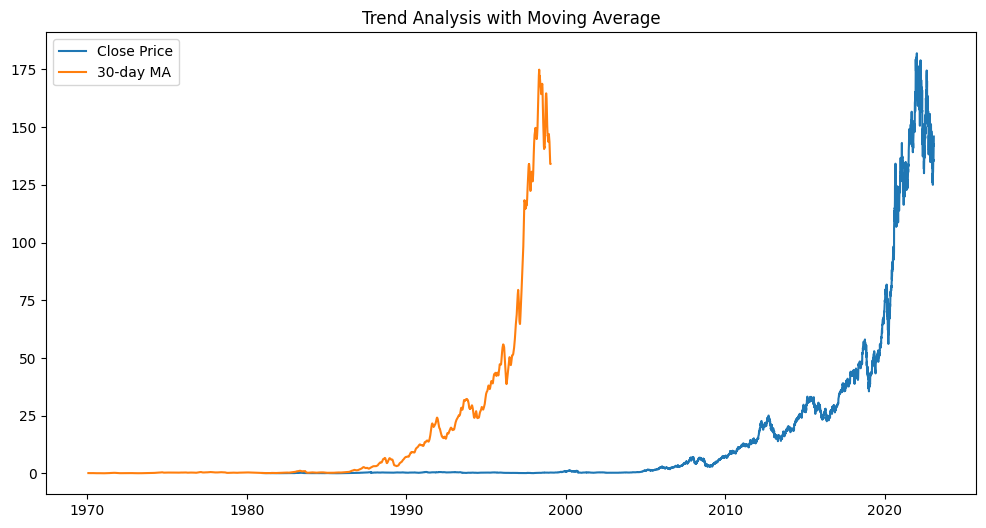

In [16]:
# rolling average (e.g., 30 days)
apple_stock["Rolling Mean 30"] = apple_stock["Close"].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(apple_stock["Date"], apple_stock["Close"], label="Close Price")
plt.plot(apple_stock["Rolling Mean 30"], label="30-day MA")

plt.legend()
plt.title("Trend Analysis with Moving Average")
plt.show()

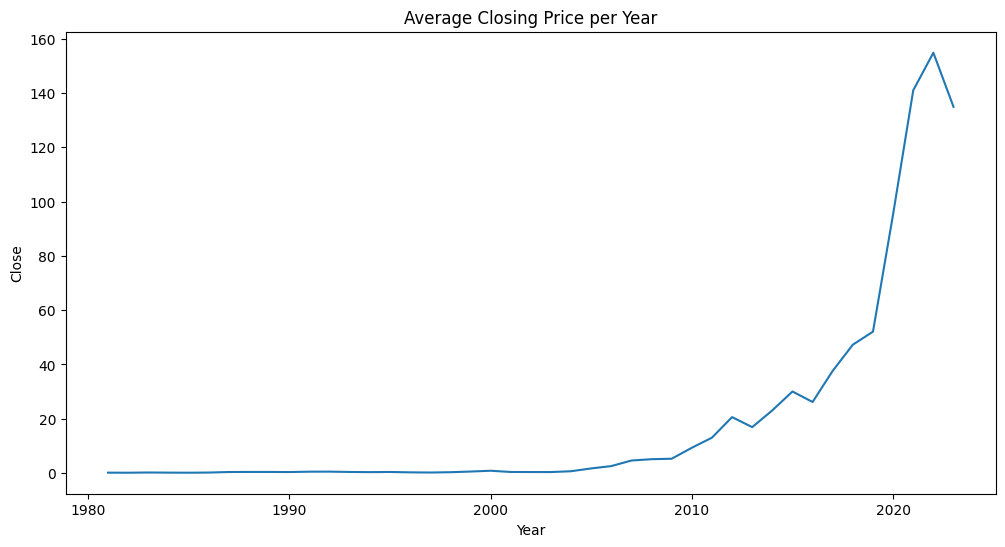

In [17]:
yearly_avg = apple_stock.groupby("Year")["Close"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_avg, x="Year", y="Close")
plt.title("Average Closing Price per Year")
plt.show()

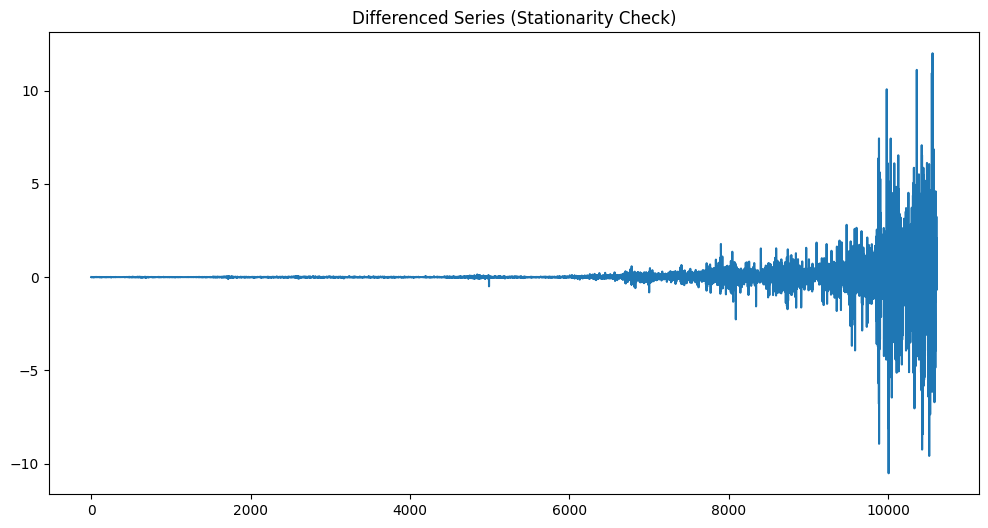

In [18]:
# difference to remove trend
apple_stock["Close_diff"] = apple_stock["Close"].diff()

plt.figure(figsize=(12,6))
plt.plot(apple_stock["Close_diff"])
plt.title("Differenced Series (Stationarity Check)")
plt.show()

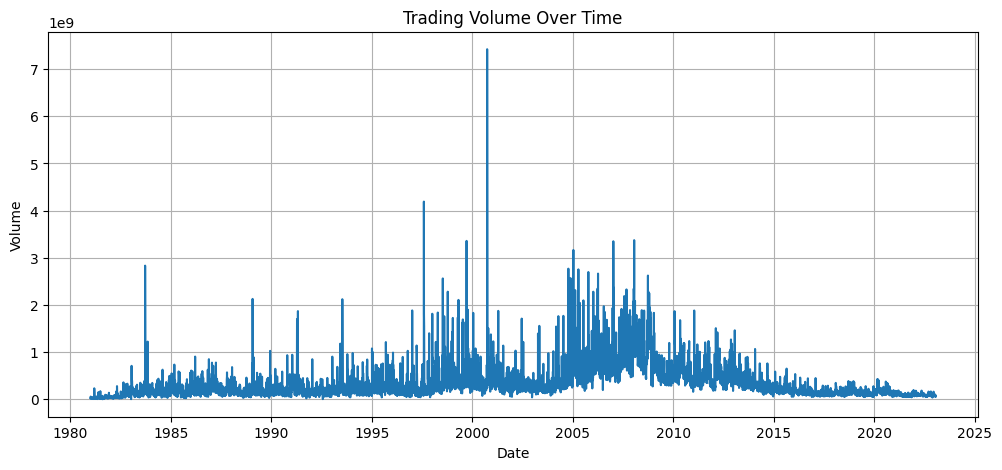

In [19]:
plt.figure(figsize=(12,5))

plt.plot(apple_stock["Date"], apple_stock["Volume"])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True)
plt.show()

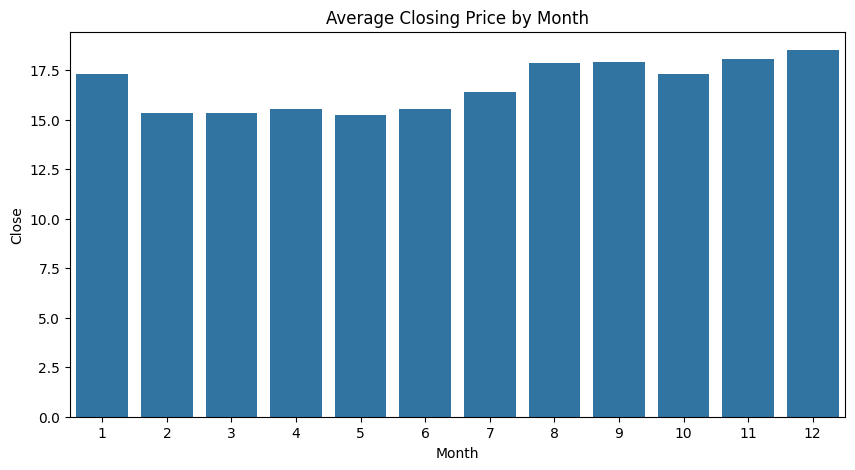

In [20]:
monthly_avg = apple_stock.groupby("Month")["Close"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=monthly_avg, x="Month", y="Close")
plt.title("Average Closing Price by Month")
plt.show()

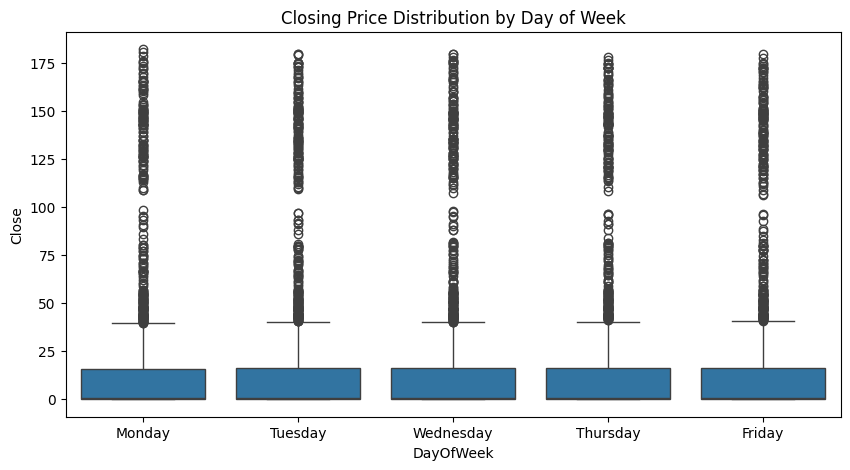

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(data=apple_stock, x="DayOfWeek", y="Close",
            order=["Monday","Tuesday","Wednesday","Thursday","Friday"])
plt.title("Closing Price Distribution by Day of Week")
plt.show()

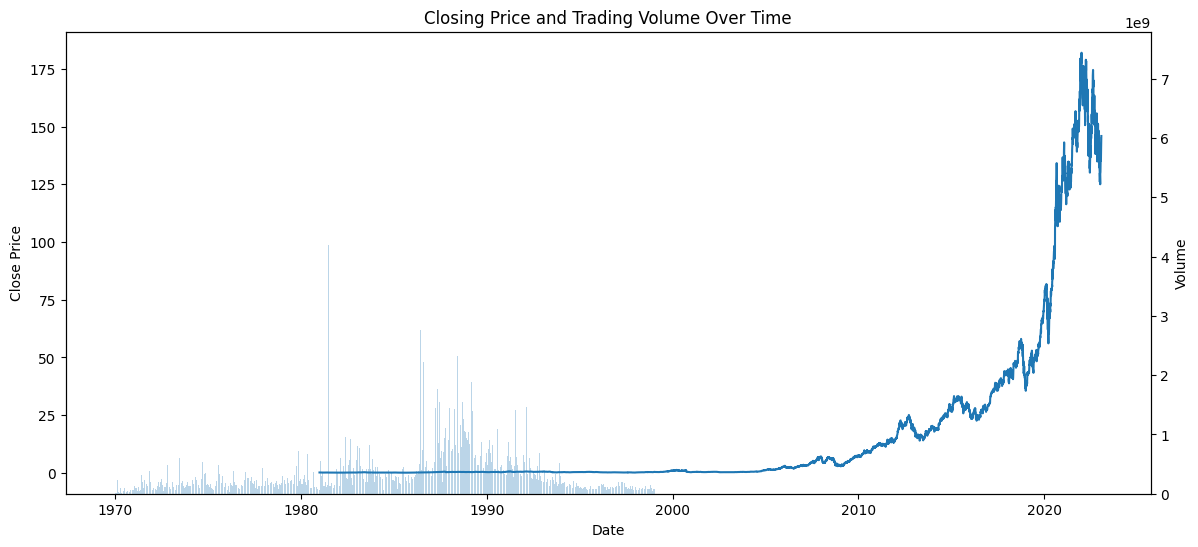

In [22]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Plot Close Price
ax1.plot(apple_stock["Date"], apple_stock["Close"])
ax1.set_xlabel("Date")
ax1.set_ylabel("Close Price")
ax1.set_title("Closing Price and Trading Volume Over Time")

# Create second axis for Volume
ax2 = ax1.twinx()
ax2.bar(apple_stock.index, apple_stock["Volume"], alpha=0.3)
ax2.set_ylabel("Volume")

plt.show()

In [23]:
numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

summary_stats = pd.DataFrame({
    "Mean": apple_stock[numeric_cols].mean(),
    "Median": apple_stock[numeric_cols].median(),
    "Std Dev": apple_stock[numeric_cols].std()
})

print(summary_stats)

                   Mean        Median       Std Dev
Open       1.668917e+01  4.888390e-01  3.545052e+01
High       1.687996e+01  4.955360e-01  3.588285e+01
Low        1.650082e+01  4.804465e-01  3.503129e+01
Close      1.669736e+01  4.877010e-01  3.547391e+01
Adj Close  1.602735e+01  4.048505e-01  3.515488e+01
Volume     3.275098e+08  2.145976e+08  3.378203e+08


In [24]:
# moving averages
apple_stock["MA_20"] = apple_stock["Close"].rolling(window=20).mean()
apple_stock["MA_50"] = apple_stock["Close"].rolling(window=50).mean()

In [25]:
apple_stock["Date"] = pd.to_datetime(apple_stock["Date"], dayfirst=True)

In [26]:
# extract year
apple_stock["Year"] = apple_stock["Date"].dt.year

year1 = 1981
year2 = 1982

data1 = apple_stock[apple_stock["Year"] == year1]["Close"]
data2 = apple_stock[apple_stock["Year"] == year2]["Close"]

In [27]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(data1, data2, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant difference in average closing prices (reject H0)")
else:
    print("No significant difference (fail to reject H0)")

T-statistic: 10.579143129232206
P-value: 1.1530548775473141e-23
Significant difference in average closing prices (reject H0)


In [28]:
years = apple_stock["Year"].unique()

for i in range(len(years)-1):
    y1, y2 = years[i], years[i+1]

    d1 = apple_stock[apple_stock["Year"] == y1]["Close"]
    d2 = apple_stock[apple_stock["Year"] == y2]["Close"]

    t_stat, p_val = ttest_ind(d1, d2, equal_var=False)

    print(f"{y1} vs {y2} → p-value: {p_val:.4f}")

1981 vs 1982 → p-value: 0.0000
1982 vs 1983 → p-value: 0.0000
1983 vs 1984 → p-value: 0.0000
1984 vs 1985 → p-value: 0.0000
1985 vs 1986 → p-value: 0.0000
1986 vs 1987 → p-value: 0.0000
1987 vs 1988 → p-value: 0.0000
1988 vs 1989 → p-value: 0.6956
1989 vs 1990 → p-value: 0.0000
1990 vs 1991 → p-value: 0.0000
1991 vs 1992 → p-value: 0.0004
1992 vs 1993 → p-value: 0.0000
1993 vs 1994 → p-value: 0.0000
1994 vs 1995 → p-value: 0.0000
1995 vs 1996 → p-value: 0.0000
1996 vs 1997 → p-value: 0.0000
1997 vs 1998 → p-value: 0.0000
1998 vs 1999 → p-value: 0.0000
1999 vs 2000 → p-value: 0.0000
2000 vs 2001 → p-value: 0.0000
2001 vs 2002 → p-value: 0.0006
2002 vs 2003 → p-value: 0.0829
2003 vs 2004 → p-value: 0.0000
2004 vs 2005 → p-value: 0.0000
2005 vs 2006 → p-value: 0.0000
2006 vs 2007 → p-value: 0.0000
2007 vs 2008 → p-value: 0.0000
2008 vs 2009 → p-value: 0.1416
2009 vs 2010 → p-value: 0.0000
2010 vs 2011 → p-value: 0.0000
2011 vs 2012 → p-value: 0.0000
2012 vs 2013 → p-value: 0.0000
2013 vs 

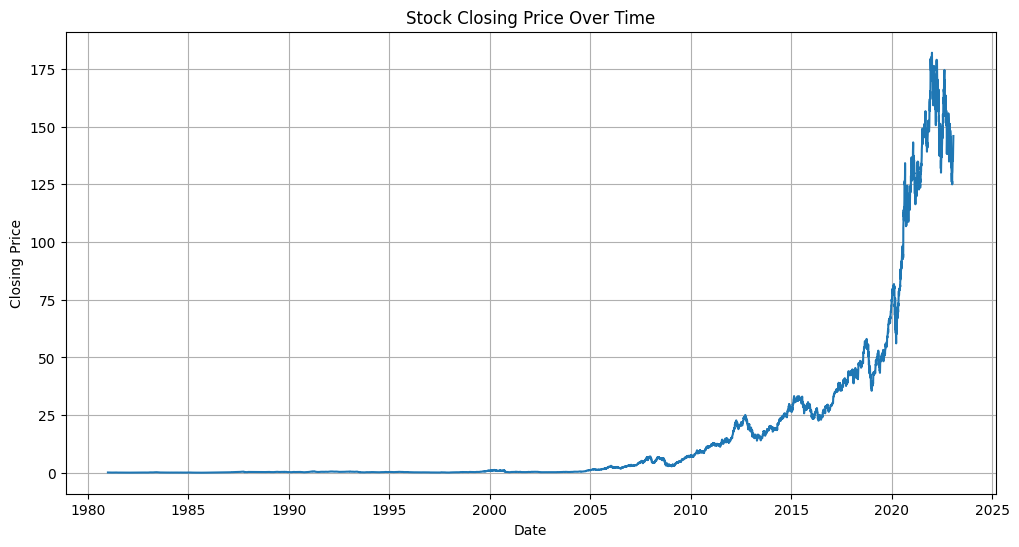

In [29]:
# sort values
apple_stock = apple_stock.sort_values("Date")

# plot
plt.figure(figsize=(12,6))
plt.plot(apple_stock["Date"], apple_stock["Close"])

plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.show()

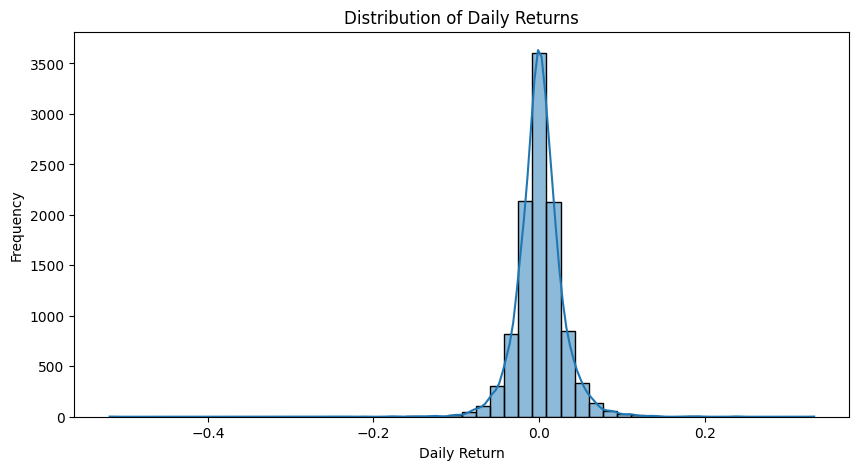

In [30]:
# calculate daily returns
apple_stock["Return"] = apple_stock["Close"].pct_change()

# drop NaN
returns = apple_stock["Return"].dropna()

plt.figure(figsize=(10,5))
sns.histplot(returns, bins=50, kde=True)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

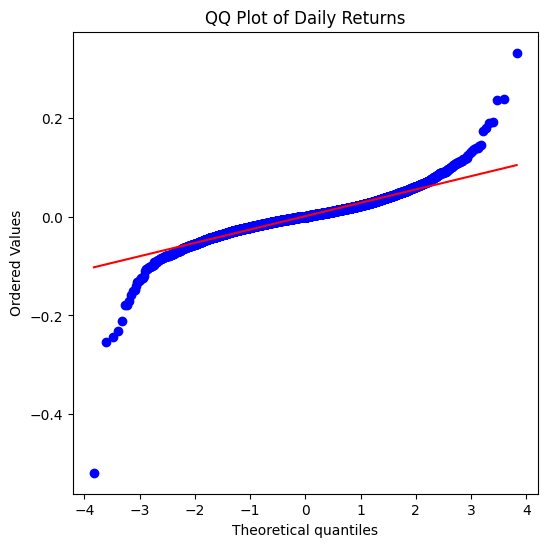

In [31]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(returns, dist="norm", plot=plt)

plt.title("QQ Plot of Daily Returns")
plt.show()

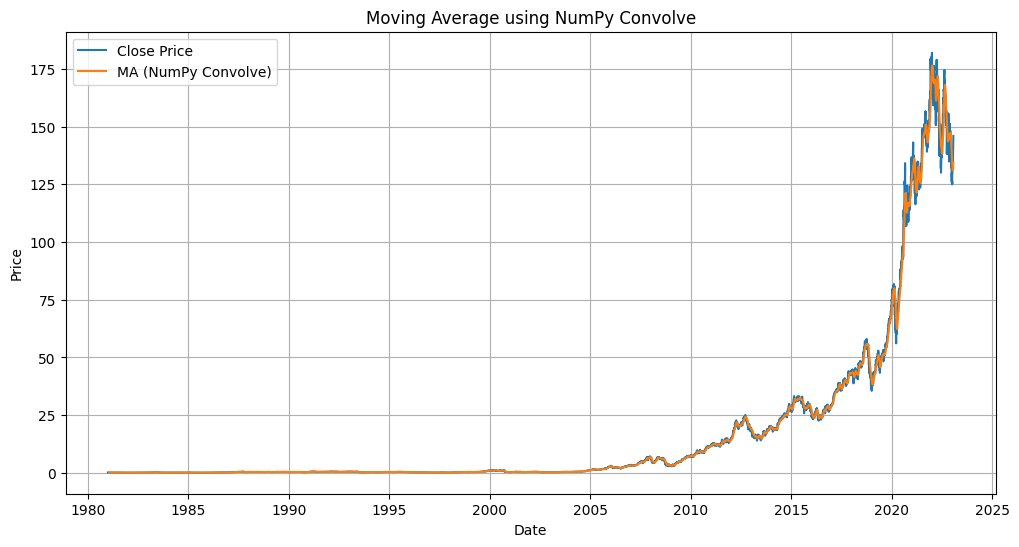

In [32]:
close_prices = apple_stock["Close"].to_numpy()

# define window
window = 20

# moving average using convolution
weights = np.ones(window) / window
ma = np.convolve(close_prices, weights, mode='valid')

# plot
plt.figure(figsize=(12,6))
plt.plot(apple_stock["Date"], close_prices, label="Close Price")
plt.plot(apple_stock["Date"][window-1:], ma, label="MA (NumPy Convolve)")

plt.legend()
plt.title("Moving Average using NumPy Convolve")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [33]:
# calculate returns
apple_stock["Return"] = apple_stock["Close"].pct_change()

# drop NaN
df_corr = apple_stock[["Close", "Volume", "Return"]].dropna()

# convert to NumPy
data = df_corr.to_numpy().T  # transpose for corrcoef

# correlation matrix
corr_matrix = np.corrcoef(data)

print("Correlation Matrix:\n", corr_matrix)

Correlation Matrix:
 [[ 1.         -0.21498375  0.00282675]
 [-0.21498375  1.          0.00147514]
 [ 0.00282675  0.00147514  1.        ]]


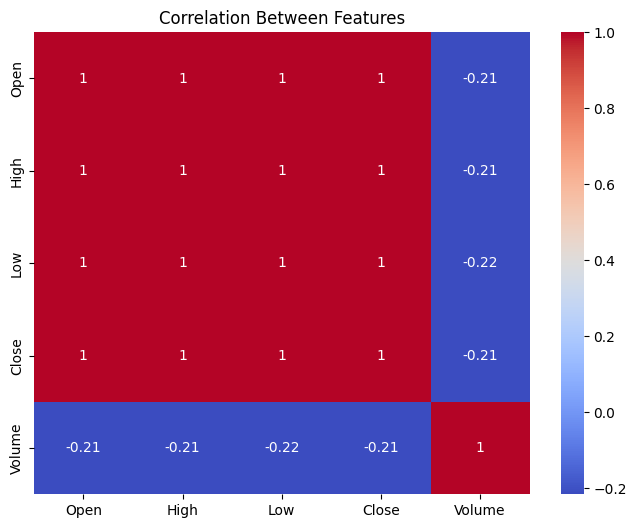

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(apple_stock[["Open","High","Low","Close","Volume"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Between Features")
plt.show()